# **Project Checkpoint 2**

**Imports**

In [ ]:
import pandas as pd

**Loading Data**

In [20]:
players = pd.read_csv(
    "datasets/kanchana1990/football-transfer-value-intelligence-2024/versions/1/Football_Player_Market_Value_Trajectories/transfermarkt_player_values.csv"
)

history = pd.read_csv(
    "datasets/kanchana1990/football-transfer-value-intelligence-2024/versions/1/Football_Player_Market_Value_Trajectories/transfermarkt_value_history.csv"
)

**Parsing + Organizing**

In [21]:
# Convert date columns in players dataset to datetime
players["peak_date"] = pd.to_datetime(players["peak_date"], errors="coerce")
players["first_date"] = pd.to_datetime(players["first_date"], errors="coerce")
players["last_date"] = pd.to_datetime(players["last_date"], errors="coerce")
players["dataset_built_at"] = pd.to_datetime(players["dataset_built_at"], errors="coerce")

# Convert valuation_date in history dataset to datetime
history["valuation_date"] = pd.to_datetime(
    history["valuation_date"], format="%d/%m/%Y", errors="coerce"
)

# Sort players alphabetically by name
players = players.sort_values(by="name").reset_index(drop=True)

# Add player names to history dataset using player_id
history["name"] = history["player_id"].map(players.set_index("player_id")["name"])

# Reorder columns so name is next to player_id
cols = history.columns.tolist()
cols.remove("name")
cols.insert(1, "name")
history = history[cols]

# Sort history by name (A-Z) and valuation_date (most recent first)
history = history.sort_values(
    by=["name", "valuation_date"],
    ascending=[True, False]
).reset_index(drop=True)

**Print Data + Check for any missing/duplicates**

In [22]:
print("\nPlayers First 5 rows:")
print(players.head())

print("\nPlayers Info:")
print(players.info())

print("\nHistory First 5 rows:")
print(history.head())

print("\nHistory Info:")
print(history.info())

print("\nMissing values per column:")
print(players.isnull().sum())

# Show rows where age OR nationality is missing
missing_rows = players[players[["age", "nationality"]].isnull().any(axis=1)]

print("\nRows with missing age or nationality:")
print(missing_rows[["player_id", "name", "age", "nationality"]])

# Fill missing age using the closest valuation date in history
best_age = (
  players.loc[players["age"].isna(), ["player_id", "last_date"]]
  .merge(
      history[["player_id", "valuation_date", "age_at_date"]],
      on="player_id",
      how="left"
  )
  .assign(date_diff=lambda df: (df["valuation_date"] - df["last_date"]).abs())
  .sort_values(["player_id", "date_diff", "valuation_date"])
  .drop_duplicates("player_id")
  .set_index("player_id")["age_at_date"]
)

players["age"] = players["age"].fillna(players["player_id"].map(best_age))

# Optional fallback in case any age is still missing
players["age"] = players["age"].fillna(players["age"].median())

# Fill nationality with placeholder
players["nationality"] = players["nationality"].fillna("Unknown")

print("\nMissing values after cleaning:")
print(players[["age", "nationality"]].isnull().sum())

print("\nCheck if any duplicates exist")
print(players.duplicated().any())



Players First 5 rows:
   player_id                name   age nationality position position_group  \
0    1145504     Aarón Anselmino  20.0   Argentina  €12.00m          Other   
1     724520     Abde Ezzalzouli  24.0     Morocco  €20.00m          Other   
2     763079  Abdukodir Khusanov  21.0  Uzbekistan  €35.00m          Other   
3     398073       Achraf Hakimi  27.0     Morocco  €80.00m          Other   
4     744149        Adam Wharton  39.0     England  €60.00m          Other   

  current_club     league_name  current_value_eur current_value_tier  ...  \
0    Argentina         Ligue 1         12000000.0    Regular (5-20M)  ...   
1      Morocco         La Liga         20000000.0       Top (20-50M)  ...   
2   Uzbekistan  Premier League         35000000.0       Top (20-50M)  ...   
3      Morocco         Ligue 1         80000000.0    Elite (50-100M)  ...   
4      England  Premier League         60000000.0    Elite (50-100M)  ...   

   mean_yoy_growth_rate num_valuation_points 

**Basic data exploration and summary statistics**

**Distribution (Descriptive stats + visualization)**

Summary Statistics for Player Market Value:
count    5.080000e+02
mean     3.686693e+07
std      2.770602e+07
min      3.000000e+05
25%      2.000000e+07
50%      2.800000e+07
75%      4.500000e+07
max      2.000000e+08
Name: current_value_eur, dtype: float64


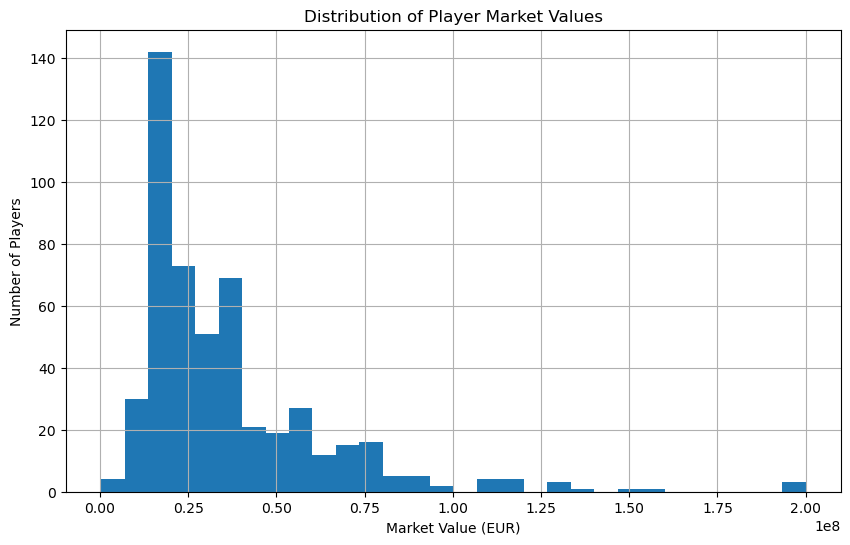

In [23]:
import matplotlib.pyplot as plt

print("Summary Statistics for Player Market Value:")
print(players["current_value_eur"].describe())

# --- Histogram (Distribution Visualization) ---
plt.figure(figsize=(10,6))

players["current_value_eur"].hist(bins=30)

plt.title("Distribution of Player Market Values")
plt.xlabel("Market Value (EUR)")
plt.ylabel("Number of Players")

plt.show()

**Descriptive Statistics and Distribution Analysis**

The dataset contains 508 players with market values measured in euros. The mean market value is approximately 36.9 million euros, while the median is 28 million euros. This means the mean is larger than the median. This means a right-skewed distribution where a small number of players have extremely high values that pull the average upward, which is shown in the graph. The standard deviation (~27.7 million euros) is relatively large, showing that player values vary significantly across the dataset. The minimum is 300,000 euros, while the maximum is 200 million euros.

The histogram visualization further supports these facts. Most players are concentrated in the lower to mid ranges, while only a few players fall into the highest ranges. This illustrates that high-value players act as outliers and contributes to the skewness of the distribution.

**Correlation Testing**

Correlation Matrix:
                       current_value_eur       age  peak_value_eur  \
current_value_eur               1.000000 -0.095507        0.899292   
age                            -0.095507  1.000000       -0.025733   
peak_value_eur                  0.899292 -0.025733        1.000000   
age_at_peak                    -0.005261  0.317910        0.059749   
career_span_years               0.035129  0.308047        0.251865   
years_to_peak                   0.085963  0.264302        0.155483   
value_cagr                     -0.024022 -0.075885       -0.035926   
value_to_peak_cagr             -0.024429 -0.074753       -0.036428   
value_multiplier_x              0.243084  0.126384        0.259119   
post_peak_decline_pct          -0.201017  0.181365        0.196785   
value_volatility               -0.154668 -0.043632       -0.262018   
mean_yoy_growth_rate           -0.057069 -0.164723       -0.128703   
num_valuation_points            0.106924  0.303364        0.320735   


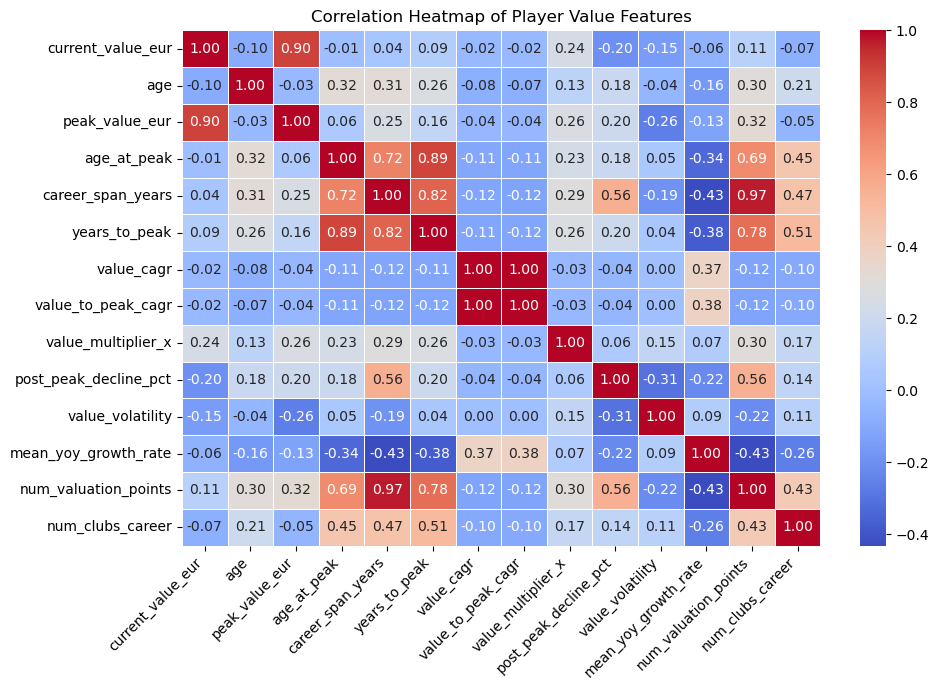

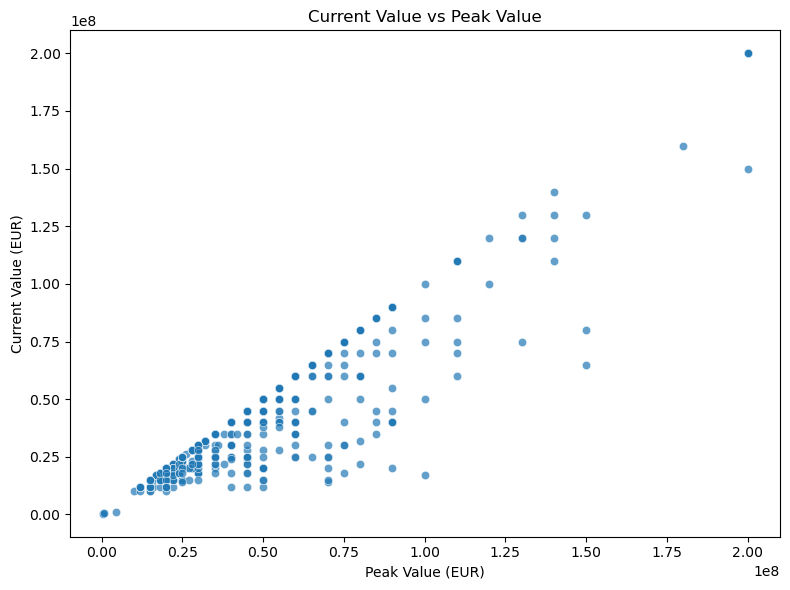

In [26]:
import seaborn as sns

corr_cols = [
    "current_value_eur",
    "age",
    "peak_value_eur",
    "age_at_peak",
    "career_span_years",
    "years_to_peak",
    "value_cagr",
    "value_to_peak_cagr",
    "value_multiplier_x",
    "post_peak_decline_pct",
    "value_volatility",
    "mean_yoy_growth_rate",
    "num_valuation_points",
    "num_clubs_career"
]

corr_df = players[corr_cols].corr()

print("Correlation Matrix:")
print(corr_df)

plt.figure(figsize=(10, 7))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Player Value Features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=players, x="peak_value_eur", y="current_value_eur", alpha=0.7)
plt.title("Current Value vs Peak Value")
plt.xlabel("Peak Value (EUR)")
plt.ylabel("Current Value (EUR)")
plt.tight_layout()
plt.show()

**Correlation Testing**

The correlation heatmap shows that the strongest relationship involving a player’s current market value is with peak_value_eur (r = 0.90), indicating that
  players who reached higher historical peak values generally still maintain higher current values. In contrast, age has only a weak negative correlation
  with current_value_eur (r = -0.10), which suggests that market value is not determined simply by whether a player is younger or older. 
  
Several of the other strong correlations also make intuitive sense because the variables measure closely related parts of a player’s career. For example, career_span_years and
  num_valuation_points are almost identical (r = 0.97) because players who have been tracked for more years naturally tend to accumulate more valuation
  records. Similarly, age_at_peak and years_to_peak are strongly correlated (r = 0.89) because players who take more years to reach their peak are usually
  older when that peak occurs. The perfect correlation between value_cagr and value_to_peak_cagr (r = 1.00) suggests these two growth measures behave nearly
  the same in this dataset.
  
In addition, mean_yoy_growth_rate has a moderate negative correlation with career_span_years (r = -0.43), which may mean that
  very large year-over-year growth is more common in shorter or earlier career periods. Finally, num_clubs_career is moderately related to years_to_peak (r =
  0.51) and career_span_years (r = 0.47), which also makes sense because players with longer careers have had more time to move between clubs, even though
  this has almost no relationship with current_value_eur (r = -0.07).

**Hypothesis Testing**